# PCA Example

Companion notebook for the blog post: *Principal Component Analysis: From Linear Algebra to Practical Dimensionality Reduction*

Uses the **sklearn Breast Cancer Wisconsin dataset** — 569 tumour samples described by 30 numeric measurements computed from digitised cell-nucleus images. The outcome column (`diagnosis`) is `malignant` or `benign`.

No separate download is needed: the dataset is built into sklearn.

**Steps covered:**
1. Load and standardize
2. Fit full PCA — inspect eigenvalues and explained variance
3. Scree plot (elbow method)
4. Cumulative variance plot (85% and 95% thresholds)
5. Choose k and project
6. Interactive biplot (plotly)
7. 2D and 3D scatter plots
8. Noise reduction / reconstruction error
9. Before/after ML comparison (logistic regression)
10. Interpreting principal components (loading analysis, feature correlations, communalities, naming)

## 1. Imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import plotly.graph_objects as go

os.makedirs("plots", exist_ok=True)
print("Imports OK")

Imports OK


## 2. Load and Standardize

In [2]:
bc = load_breast_cancer()

features = list(bc.feature_names)
df = pd.DataFrame(bc.data, columns=features)
df["diagnosis"] = pd.Categorical.from_codes(bc.target, ["malignant", "benign"])

print(f"Dataset shape: {df.shape}")
print(f"\nDiagnosis counts:")
print(df["diagnosis"].value_counts())
print()
df[features].describe().round(2)

Dataset shape: (569, 31)

Diagnosis counts:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features].values)

print(f"Scaled shape: {X_scaled.shape}")
print(f"Column means (should be ~0): {X_scaled.mean(axis=0).round(3)[:5]} ...")
print(f"Column stds  (should be ~1): {X_scaled.std(axis=0).round(3)[:5]} ...")

Scaled shape: (569, 30)
Column means (should be ~0): [-0.  0. -0. -0. -0.] ...
Column stds  (should be ~1): [1. 1. 1. 1. 1.] ...


## 3. Fit Full PCA (all 30 components)

Fitting with all 30 components first lets us inspect the full eigenvalue spectrum before choosing how many to retain.

In [4]:
pca_full = PCA(n_components=30, random_state=42)
pca_full.fit(X_scaled)

evr    = pca_full.explained_variance_ratio_
cumev  = np.cumsum(evr)
eigvals = pca_full.explained_variance_

print("Component  Eigenvalue   EVR      Cumulative EVR  Kaiser (>1?)")
print("-" * 65)
for i, (ev, e, c) in enumerate(zip(evr, eigvals, cumev), start=1):
    kaiser = "YES" if e > 1.0 else ""
    print(f"  PC{i:2d}      {e:7.3f}    {ev:.4f}    {c:.4f}           {kaiser}")

Component  Eigenvalue   EVR      Cumulative EVR  Kaiser (>1?)
-----------------------------------------------------------------
  PC 1       13.305    0.4427    0.4427           YES
  PC 2        5.701    0.1897    0.6324           YES
  PC 3        2.823    0.0939    0.7264           YES
  PC 4        1.984    0.0660    0.7924           YES
  PC 5        1.652    0.0550    0.8473           YES
  PC 6        1.209    0.0402    0.8876           YES
  PC 7        0.676    0.0225    0.9101           
  PC 8        0.477    0.0159    0.9260           
  PC 9        0.418    0.0139    0.9399           
  PC10        0.351    0.0117    0.9516           
  PC11        0.294    0.0098    0.9614           
  PC12        0.262    0.0087    0.9701           
  PC13        0.242    0.0080    0.9781           
  PC14        0.157    0.0052    0.9834           
  PC15        0.094    0.0031    0.9865           
  PC16        0.080    0.0027    0.9892           
  PC17        0.060    0.0020    0.991

## 4. Scree Plot

Bar chart of explained variance ratio per component with a line overlay.  
Look for the **elbow** — the point where adding another component yields diminishing returns.

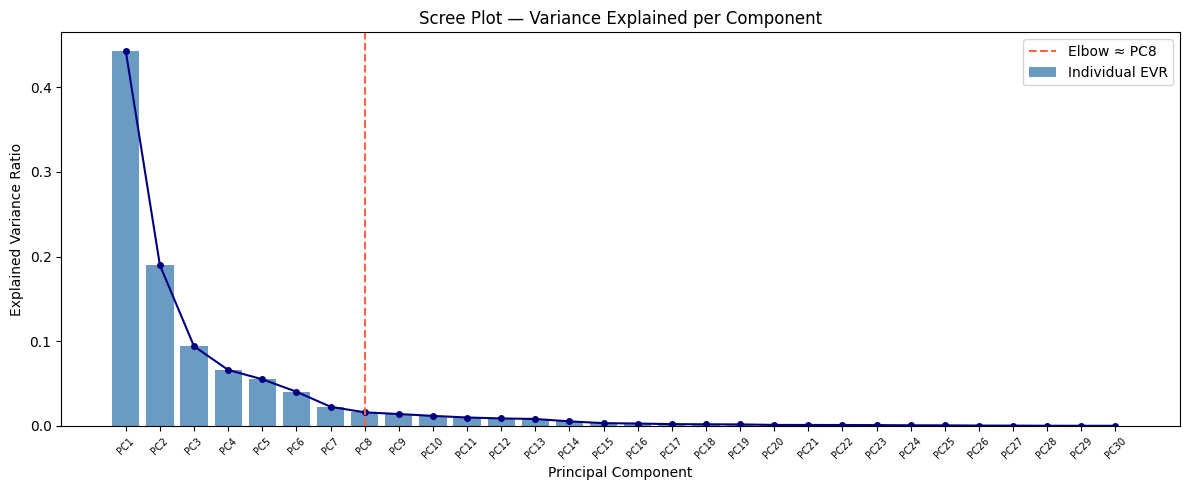

Saved plots/pca_scree_plot.png


In [5]:
n_comp = len(evr)
x_pos  = np.arange(1, n_comp + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos, evr, color="steelblue", alpha=0.8, label="Individual EVR")
ax.plot(x_pos, evr, "o-", color="navy", linewidth=1.5, markersize=4)

# Mark elbow — first position where the drop between consecutive components exceeds 0.02
deltas = np.diff(evr)
elbow_idx = int(np.argmax(np.abs(deltas[3:]) < 0.01)) + 4 + 1  # skip first 3 large drops
ax.axvline(elbow_idx, color="tomato", linestyle="--", linewidth=1.5,
           label=f"Elbow ≈ PC{elbow_idx}")

ax.set_xticks(x_pos)
ax.set_xticklabels([f"PC{i}" for i in x_pos], fontsize=7, rotation=45)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — Variance Explained per Component")
ax.legend()
plt.tight_layout()
plt.savefig("plots/pca_scree_plot.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_scree_plot.png")

## 5. Cumulative Variance Plot

Shows how much total variance is retained as we add more components.  
Reference lines at **85%** and **95%** are common thresholds in practice.

Components to reach 85% variance: 6
Components to reach 95% variance: 10


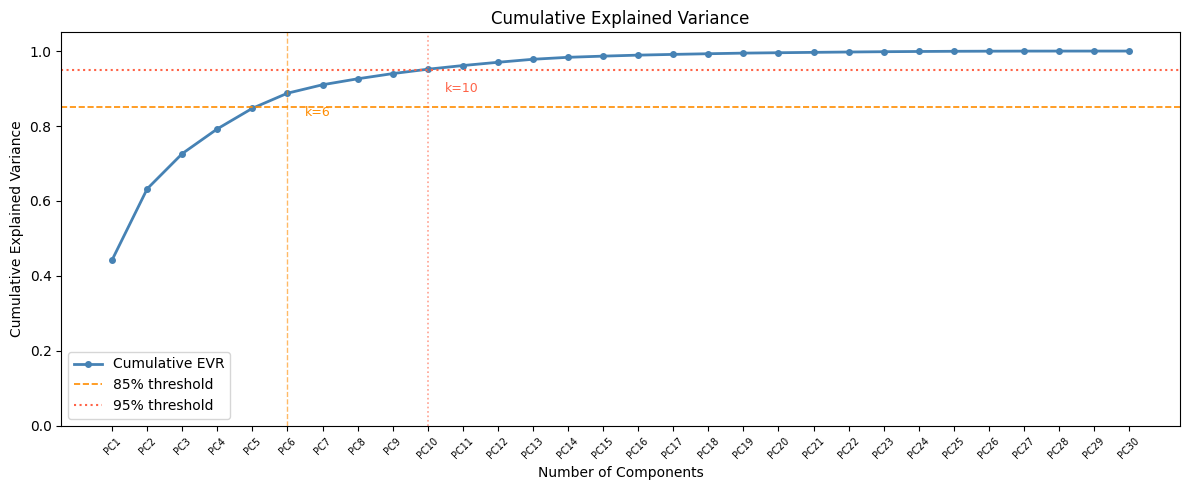

Saved plots/pca_cumulative_variance.png


In [6]:
k85 = int(np.argmax(cumev >= 0.85)) + 1
k95 = int(np.argmax(cumev >= 0.95)) + 1

print(f"Components to reach 85% variance: {k85}")
print(f"Components to reach 95% variance: {k95}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_pos, cumev, "o-", color="steelblue", linewidth=2, markersize=4,
        label="Cumulative EVR")

ax.axhline(0.85, color="darkorange", linestyle="--", linewidth=1.2, label="85% threshold")
ax.axhline(0.95, color="tomato",    linestyle=":",  linewidth=1.5, label="95% threshold")

ax.axvline(k85, color="darkorange", linestyle="--", linewidth=1.0, alpha=0.6)
ax.axvline(k95, color="tomato",    linestyle=":",  linewidth=1.2, alpha=0.6)

ax.annotate(f"k={k85}", xy=(k85, cumev[k85-1]), xytext=(k85+0.5, cumev[k85-1]-0.06),
            color="darkorange", fontsize=9)
ax.annotate(f"k={k95}", xy=(k95, cumev[k95-1]), xytext=(k95+0.5, cumev[k95-1]-0.06),
            color="tomato", fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"PC{i}" for i in x_pos], fontsize=7, rotation=45)
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_ylim(0, 1.05)
ax.set_title("Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.savefig("plots/pca_cumulative_variance.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_cumulative_variance.png")

## 6. Choose k and Project

The three selection methods converge on a small number of components:
- **Kaiser criterion** (eigenvalue > 1): 6 components
- **85% threshold**: 6 components  
- **Scree elbow**: around PC5–PC7

All three agree on **k = 6**, retaining 88.8% of the total variance while reducing 30 dimensions to 6.

In [7]:
kaiser_k = int(np.sum(eigvals > 1.0))
print(f"Kaiser criterion suggests: k = {kaiser_k} (eigenvalue > 1)")
print(f"85% threshold suggests:    k = {k85}")
print()

K = k85
print(f"Selected K = {K}")

pca_k = PCA(n_components=K, random_state=42)
Z = pca_k.fit_transform(X_scaled)

retained = pca_k.explained_variance_ratio_.sum()
print(f"Shape of projected data Z: {Z.shape}")
print(f"Total variance retained:   {retained:.4f} ({retained*100:.1f}%)")
print(f"Dimensionality reduction:  30 features → {K} components ({K/30*100:.0f}% of original dimensions)")

Kaiser criterion suggests: k = 6 (eigenvalue > 1)
85% threshold suggests:    k = 6

Selected K = 6
Shape of projected data Z: (569, 6)
Total variance retained:   0.8876 (88.8%)
Dimensionality reduction:  30 features → 6 components (20% of original dimensions)


## 7. Biplot (Interactive)

A **biplot** overlays two things in PCA space:
- **Points** — each tumour sample projected onto PC1 and PC2, colored by `diagnosis`
- **Arrows** — each feature's loading vector showing direction and strength of contribution

With 30 features the arrows overlap, so abbreviated labels are used. Hover over points in the interactive version to see individual sample details.

Saved plots/pca_biplot.png


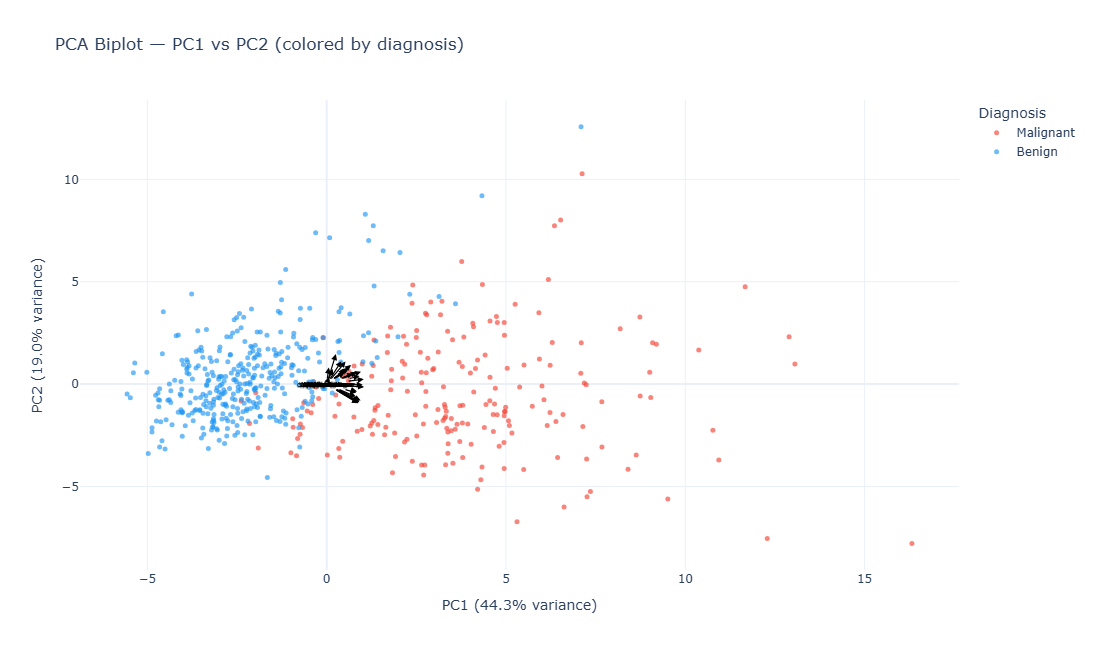

In [8]:
loadings   = pca_full.components_[:2]   # shape (2, 30)
Z_full     = pca_full.transform(X_scaled)
scale      = 4.0

diagnoses  = ["malignant", "benign"]
colors_map = {"malignant": "#F44336", "benign": "#2196F3"}
diag_vals  = df["diagnosis"].astype(str).values

fig = go.Figure()

for diag in diagnoses:
    mask = diag_vals == diag
    fig.add_trace(go.Scatter(
        x=Z_full[mask, 0],
        y=Z_full[mask, 1],
        mode="markers",
        name=diag.capitalize(),
        marker=dict(color=colors_map[diag], size=5, opacity=0.65),
    ))

# Abbreviate feature names for readability
def abbrev(name):
    return (name.replace("mean ", "μ ")
                .replace("worst ", "W ")
                .replace(" error", " err")
                .replace("concave points", "cv.pts")
                .replace("fractal dimension", "frac.dim"))

for i, feat in enumerate(features):
    fig.add_annotation(
        x=loadings[0, i] * scale, y=loadings[1, i] * scale,
        ax=0, ay=0,
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=2, arrowsize=1,
        arrowwidth=1.2, arrowcolor="black",
        text=abbrev(feat),
        font=dict(size=7, color="black"),
    )

fig.update_layout(
    title="PCA Biplot — PC1 vs PC2 (colored by diagnosis)",
    xaxis_title=f"PC1 ({evr[0]*100:.1f}% variance)",
    yaxis_title=f"PC2 ({evr[1]*100:.1f}% variance)",
    legend_title="Diagnosis",
    width=900, height=650,
    template="plotly_white",
)

try:
    fig.write_image("plots/pca_biplot.png")
    print("Saved plots/pca_biplot.png")
except Exception as e:
    print(f"PNG export failed (install kaleido: pip install kaleido): {e}")

fig.show()

## 8. 2D and 3D Scatter Plots

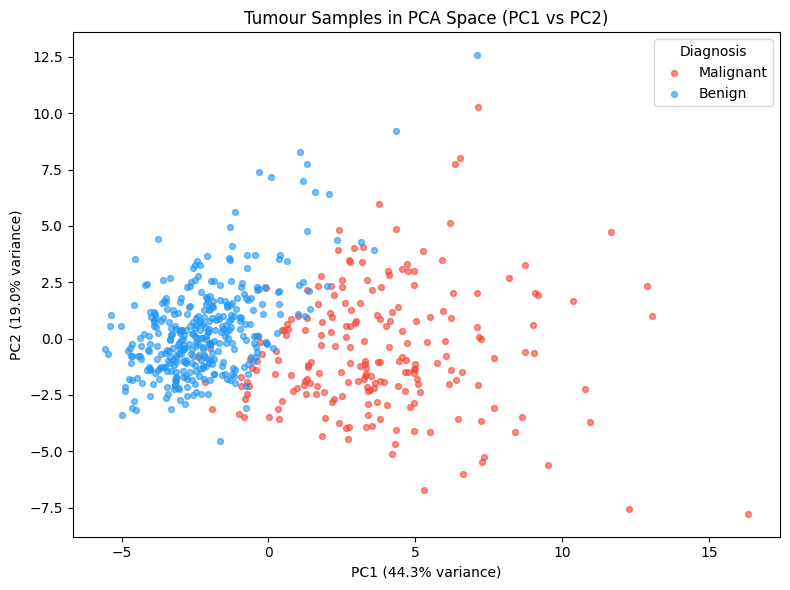

Saved plots/pca_patient_scatter_2d.png


In [9]:
# 2D scatter — PC1 vs PC2
fig2d, ax2d = plt.subplots(figsize=(8, 6))
for diag in diagnoses:
    mask = diag_vals == diag
    ax2d.scatter(Z_full[mask, 0], Z_full[mask, 1],
                 c=colors_map[diag], alpha=0.6, s=18, label=diag.capitalize())

ax2d.set_xlabel(f"PC1 ({evr[0]*100:.1f}% variance)")
ax2d.set_ylabel(f"PC2 ({evr[1]*100:.1f}% variance)")
ax2d.set_title("Tumour Samples in PCA Space (PC1 vs PC2)")
ax2d.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("plots/pca_patient_scatter_2d.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_patient_scatter_2d.png")

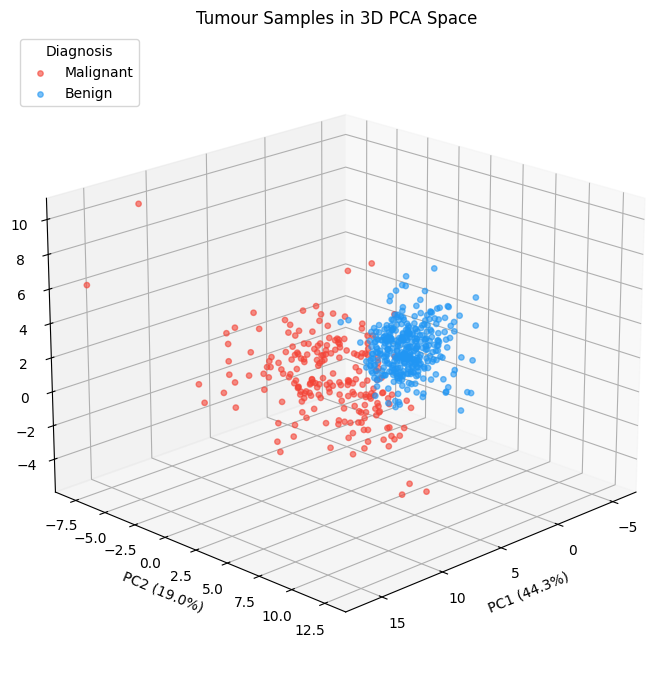

Saved plots/pca_3d_scatter.png


In [10]:
# 3D scatter — PC1, PC2, PC3
fig3d = plt.figure(figsize=(9, 7))
ax3d  = fig3d.add_subplot(111, projection="3d")

for diag in diagnoses:
    mask = diag_vals == diag
    ax3d.scatter(Z_full[mask, 0], Z_full[mask, 1], Z_full[mask, 2],
                 c=colors_map[diag], alpha=0.6, s=15, label=diag.capitalize())

ax3d.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax3d.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax3d.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)")
ax3d.set_title("Tumour Samples in 3D PCA Space")
ax3d.legend(title="Diagnosis", loc="upper left")
ax3d.view_init(elev=20, azim=45)
plt.tight_layout()
plt.savefig("plots/pca_3d_scatter.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_3d_scatter.png")

## 9. Noise Reduction / Reconstruction

Reconstructing data from k PCA components (instead of all 30) acts as a low-pass filter —
high-frequency variation in the low-variance components (often noise) is discarded.  
The reconstruction error curve shows how quickly MSE drops as we add more components.

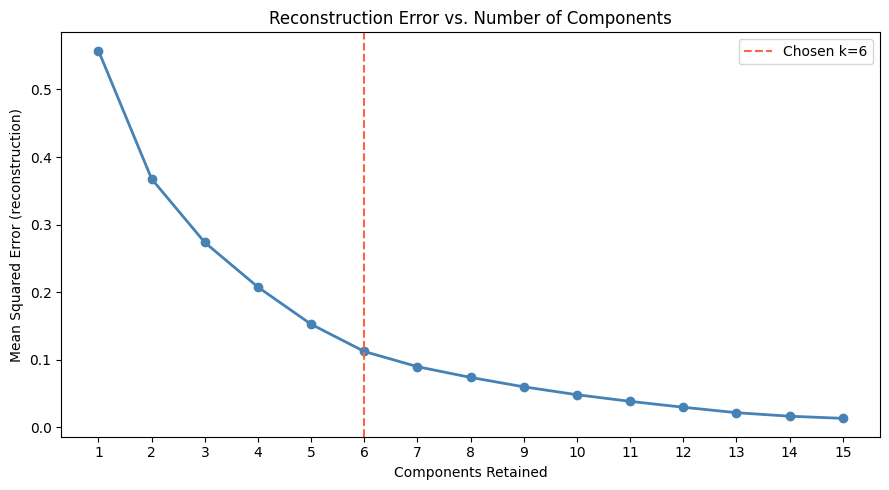

Saved plots/pca_reconstruction_error.png
MSE at k=6: 0.1124
MSE at k=15: 0.0135


In [11]:
mse_values = []
k_range = list(range(1, 16))  # 1 to 15 components

for k in k_range:
    pca_tmp = PCA(n_components=k, random_state=42).fit(X_scaled)
    Z_tmp   = pca_tmp.transform(X_scaled)
    X_recon = pca_tmp.inverse_transform(Z_tmp)
    mse     = mean_squared_error(X_scaled, X_recon)
    mse_values.append(mse)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, mse_values, "o-", color="steelblue", linewidth=2, markersize=6)
ax.axvline(K, color="tomato", linestyle="--", linewidth=1.5, label=f"Chosen k={K}")
ax.set_xticks(k_range)
ax.set_xlabel("Components Retained")
ax.set_ylabel("Mean Squared Error (reconstruction)")
ax.set_title("Reconstruction Error vs. Number of Components")
ax.legend()
plt.tight_layout()
plt.savefig("plots/pca_reconstruction_error.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_reconstruction_error.png")
print(f"MSE at k={K}: {mse_values[K-1]:.4f}")
print(f"MSE at k=15: {mse_values[14]:.4f}")

## 10. Before/After ML Comparison

Train a logistic regression classifier on:
1. All 12 raw standardized features
2. The top-k PCA components

Compare 3-fold cross-validated accuracy and training time.

In [12]:
y = bc.target   # 0 = malignant, 1 = benign
clf = LogisticRegression(max_iter=5000, random_state=42)

# --- Raw features (30) ---
t0 = time.perf_counter()
scores_raw = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
t_raw = (time.perf_counter() - t0) * 1000

print(f"Raw features (30):")
print(f"  CV accuracy: {scores_raw.mean():.4f} ± {scores_raw.std():.4f}")
print(f"  Time:        {t_raw:.1f} ms")

Raw features (30):
  CV accuracy: 0.9807 ± 0.0065
  Time:        39.3 ms


In [13]:
# --- PCA components (k=K) ---
t0         = time.perf_counter()
scores_pca = cross_val_score(clf, Z, y, cv=5, scoring="accuracy")
t_pca      = (time.perf_counter() - t0) * 1000  # ms

print(f"PCA components (k={K}):")
print(f"  CV accuracy: {scores_pca.mean():.4f} ± {scores_pca.std():.4f}")
print(f"  Time:        {t_pca:.1f} ms")

PCA components (k=6):
  CV accuracy: 0.9719 ± 0.0102
  Time:        30.7 ms


In [14]:
# Summary table
print(f"{'':30s}  {'Raw features':>15}  {'PCA components':>15}")
print("-" * 65)
print(f"{'Features used':30s}  {'30':>15}  {str(K):>15}")
print(f"{'CV Accuracy (mean)':30s}  {scores_raw.mean():>15.4f}  {scores_pca.mean():>15.4f}")
print(f"{'CV Accuracy (std)':30s}  {scores_raw.std():>15.4f}  {scores_pca.std():>15.4f}")
print(f"{'Training time (ms)':30s}  {t_raw:>15.1f}  {t_pca:>15.1f}")
print(f"{'Variance retained':30s}  {'100%':>15}  {retained*100:>14.1f}%")
print(f"{'Feature-interpretable':30s}  {'Partially':>15}  {'No':>15}")

                                   Raw features   PCA components
-----------------------------------------------------------------
Features used                                30                6
CV Accuracy (mean)                       0.9807           0.9719
CV Accuracy (std)                        0.0065           0.0102
Training time (ms)                         39.3             30.7
Variance retained                          100%            88.8%
Feature-interpretable                 Partially               No


## 11. Interpreting Principal Components

PCA components are linear combinations of all original features — they don't map cleanly to any single measurement. But several techniques let you recover meaningful interpretation after the fact.

**Methods covered here:**
1. **Loading analysis** — which features drive each component (top positive/negative weights)
2. **Loading heatmap** — full feature × component view at a glance
3. **Correlation with original features** — familiar −1 to +1 scale, easy to present to non-technical audiences
4. **Communality** — how much of each feature's variance survives the dimensionality reduction
5. **Naming components** — validating a proposed label against the `condition` groups

In [15]:
# --- 11a. Loading Analysis ---
# With 30 features, printing all loadings is noisy.
# Focus on the top 5 positive and negative contributors per component.

loadings_df = pd.DataFrame(
    pca_full.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(30)]
)

print("Top 5 positive and negative contributors for the first 6 PCs:\n")
for pc in [f"PC{i+1}" for i in range(6)]:
    top_pos = loadings_df[pc].nlargest(5)
    top_neg = loadings_df[pc].nsmallest(3)
    print(f"{pc}:")
    print("  + " + ", ".join(f"{f} ({v:+.3f})" for f, v in top_pos.items()))
    print("  - " + ", ".join(f"{f} ({v:+.3f})" for f, v in top_neg.items()))
    print()

Top 5 positive and negative contributors for the first 6 PCs:

PC1:
  + mean concave points (+0.261), mean concavity (+0.258), worst concave points (+0.251), mean compactness (+0.239), worst perimeter (+0.237)
  - smoothness error (+0.015), texture error (+0.017), symmetry error (+0.042)

PC2:
  + mean fractal dimension (+0.367), fractal dimension error (+0.280), worst fractal dimension (+0.275), compactness error (+0.233), smoothness error (+0.204)
  - mean radius (-0.234), mean area (-0.231), worst radius (-0.220)

PC3:
  + texture error (+0.375), smoothness error (+0.309), symmetry error (+0.289), radius error (+0.268), perimeter error (+0.267)
  - worst symmetry (-0.271), worst smoothness (-0.260), worst compactness (-0.236)

PC4:
  + worst texture (+0.633), mean texture (+0.603), texture error (+0.360), worst compactness (+0.091), worst fractal dimension (+0.077)
  - mean smoothness (-0.159), area error (-0.108), radius error (-0.098)

PC5:
  + mean smoothness (+0.365), worst smoo

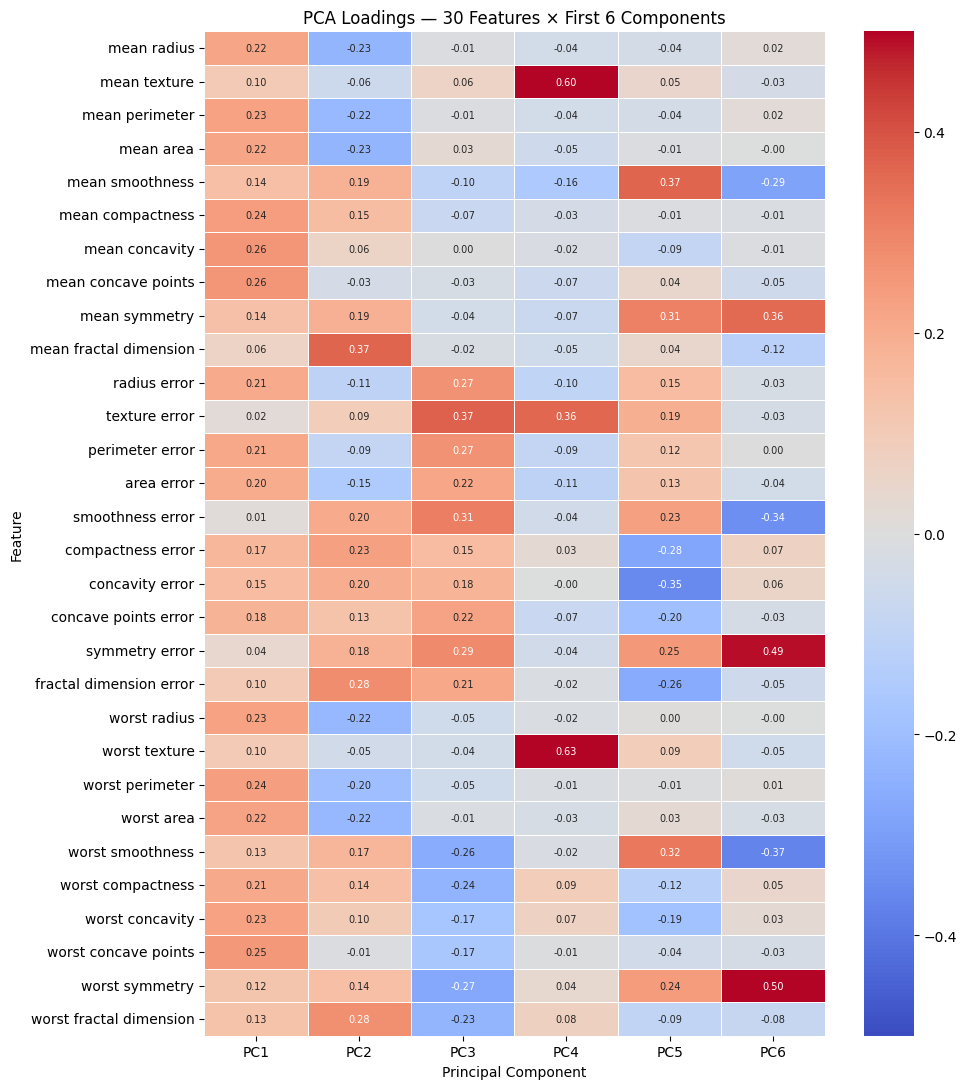

Saved plots/pca_loading_heatmap.png


In [16]:
# --- 11b. Loading Heatmap ---
# Show loadings for the first 6 components across all 30 features.

fig, ax = plt.subplots(figsize=(10, 11))
sns.heatmap(
    loadings_df.iloc[:, :6],
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("PCA Loadings — 30 Features × First 6 Components")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("plots/pca_loading_heatmap.png", dpi=150)
plt.show()
plt.close()
print("Saved plots/pca_loading_heatmap.png")

In [17]:
# --- 11c. Correlation of PC Scores with Original Features ---
Z_full_df   = pd.DataFrame(Z_full, columns=[f"PC{i+1}" for i in range(30)])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

corr_matrix  = pd.concat([Z_full_df.iloc[:, :6], X_scaled_df], axis=1).corr()
pc_feat_corr = corr_matrix.loc[features, [f"PC{i+1}" for i in range(6)]]

print("Pearson correlation between PC scores and original features (top 10 by |PC1|):\n")
top10 = pc_feat_corr["PC1"].abs().nlargest(10).index
print(pc_feat_corr.loc[top10].round(3).to_string())
print()
print("Features with |correlation| > 0.5 are strong contributors to that PC.")

Pearson correlation between PC scores and original features (top 10 by |PC1|):

                        PC1    PC2    PC3    PC4    PC5    PC6
mean concave points   0.951 -0.083 -0.043 -0.092  0.056 -0.057
mean concavity        0.942  0.144  0.005 -0.027 -0.111 -0.010
worst concave points  0.914 -0.020 -0.286 -0.008 -0.056 -0.034
mean compactness      0.872  0.362 -0.124 -0.045 -0.015 -0.016
worst perimeter       0.862 -0.477 -0.081 -0.019 -0.010  0.009
worst concavity       0.834  0.234 -0.291  0.104 -0.242  0.031
worst radius          0.831 -0.525 -0.080 -0.022  0.006 -0.000
mean perimeter        0.829 -0.513 -0.016 -0.059 -0.048  0.019
worst area            0.820 -0.523 -0.020 -0.036  0.035 -0.028
mean area             0.805 -0.551  0.048 -0.075 -0.013 -0.002

Features with |correlation| > 0.5 are strong contributors to that PC.


In [18]:
# --- 11d. Communality — fraction of each feature's variance retained in top-K PCs ---
# With 30 features and K=6 (20% of dimensions), a communality of 0.3–0.5 is expected
# for features that don't dominate any single component. A near-1.0 communality means
# almost all of that feature's variance is captured; a low value means it is mostly
# discarded — relevant if that feature matters for your downstream task.

communalities = np.sum(pca_full.components_[:K] ** 2, axis=0)
comm_df = pd.Series(communalities, index=features).sort_values(ascending=False)

print(f"Fraction of each feature's variance retained in top-{K} PCs:\n")
for feat, val in comm_df.items():
    bar  = "█" * int(val * 20)
    flag = "  ← low" if val < 0.25 else ""
    print(f"  {feat:40s}  {val:.3f}  {bar}{flag}")

print()
print(f"Note: with K={K} out of 30 components (20% of dimensions), communalities in")
print(f"the 0.3–0.6 range are normal. Only features flagged ← low (<0.25) are")
print(f"substantially discarded by the reduction.")

Fraction of each feature's variance retained in top-6 PCs:

  worst texture                             0.426  ████████
  symmetry error                            0.425  ████████
  worst symmetry                            0.419  ████████
  mean texture                              0.386  ███████
  worst smoothness                          0.355  ███████
  texture error                             0.316  ██████
  smoothness error                          0.311  ██████
  mean smoothness                           0.307  ██████
  mean symmetry                             0.282  █████
  concavity error                           0.222  ████  ← low
  fractal dimension error                   0.206  ████  ← low
  compactness error                         0.191  ███  ← low
  worst fractal dimension                   0.169  ███  ← low
  radius error                              0.160  ███  ← low
  mean fractal dimension                    0.158  ███  ← low
  perimeter error                    

In [19]:
# --- 11e. Naming Components — validate proposed labels against known groups ---
# Workflow:
# 1. Inspect top loadings (cell 11a) to propose a domain label for each PC.
# 2. Compute mean PC score per diagnosis group (malignant vs. benign).
# 3. Check that groups separate on the components whose loadings you used to
#    name them. If malignant tumours score much higher on the "Shape Severity Axis"
#    PC, and that PC loads on mean concave points / mean concavity / mean compactness,
#    the label is credible.

Z_full_df["diagnosis"] = df["diagnosis"].astype(str).values

print("Mean PC score per diagnosis group:\n")
group_means = Z_full_df.groupby("diagnosis")[[f"PC{i+1}" for i in range(6)]].mean()
print(group_means.round(3).to_string())

print()
print("How to use this table:")
print("  1. Look at which PC shows the largest spread between malignant and benign.")
print("  2. Cross-reference with the top loadings in cell 11a.")
print("  3. PC1 loads on mean concave points / mean concavity / worst concave points.")
print("     If malignant samples score much higher on PC1, a label like")
print("     'Shape Severity Axis' is credible — the PC encodes irregular shape")
print("     and malignancy tracks with concavity.")
print("  4. PC2 loads on fractal dimension (mean, error, worst) and has negative")
print("     loadings on mean radius / mean area / worst radius. If both diagnosis")
print("     groups score similarly on PC2, that PC captures boundary complexity")
print("     variation largely independent of malignancy — a separate geometric axis.")
print("  5. PC4 loads almost entirely on worst texture and mean texture.")
print("     It represents cell-nucleus texture and should show less separation")
print("     between malignant and benign groups than PC1.")

Mean PC score per diagnosis group:

             PC1    PC2    PC3    PC4    PC5    PC6
diagnosis                                          
benign    -2.206  0.346  0.213 -0.138 -0.098  0.010
malignant  3.715 -0.583 -0.359  0.233  0.165 -0.016

How to use this table:
  1. Look at which PC shows the largest spread between malignant and benign.
  2. Cross-reference with the top loadings in cell 11a.
  3. PC1 loads on mean concave points / mean concavity / worst concave points.
     If malignant samples score much higher on PC1, a label like
     'Shape Severity Axis' is credible — the PC encodes irregular shape
     and malignancy tracks with concavity.
  4. PC2 loads on fractal dimension (mean, error, worst) and has negative
     loadings on mean radius / mean area / worst radius. If both diagnosis
     groups score similarly on PC2, that PC captures boundary complexity
     variation largely independent of malignancy — a separate geometric axis.
  5. PC4 loads almost entirely on worst 

---

## Summary

This notebook demonstrated the complete PCA workflow on the sklearn Breast Cancer Wisconsin dataset (569 samples, 30 features):

1. **Standardize** — mandatory before PCA; all features must be on the same scale
2. **Fit PCA with all components** — inspect the full eigenvalue spectrum
3. **Choose k** using the convergence of three methods: scree elbow, cumulative EVR threshold (85%), and Kaiser criterion — all point to **k = 6**, retaining 88.8% of variance
4. **Visualize** with a biplot (feature loadings + tumour scores) and 2D/3D scatter plots — malignant and benign tumours separate clearly on PC1
5. **Reconstruction error** confirms that the low-variance tail carries little information; MSE drops steeply in the first few components
6. **ML comparison** shows that a classifier trained on k=6 PCA components achieves similar cross-validated accuracy (~97%) compared to all 30 raw features (~98%), with faster training
7. **Interpret** components via loading analysis, heatmap, PC–feature correlations, communalities, and mean-score-by-group validation

The companion blog post provides the full mathematical derivation and additional context:  
*Principal Component Analysis: From Linear Algebra to Practical Dimensionality Reduction*